# Gentrification Classification – Presentation Notebook

This notebook collects the **key visuals** for a 4‑minute presentation:

- Rent growth distribution and label definition (high vs normal growth)
- Class balance and model performance metrics
- Feature importance (which Yelp / gentrification signals matter)
- Spatial maps of rent growth and gentrification intensity by ZIP code

The notebook assumes you have already run `main.py` so that:

- `data/classification_data.csv`
- `outputs/classification_results.csv`
- `outputs/classification_feature_importance.csv`

are available.



In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: for maps
try:
    import folium
    import pgeocode
except ImportError:
    folium = None
    pgeocode = None
    print("Install folium and pgeocode for maps: pip install folium pgeocode")

# Set a clean style
sns.set(style="whitegrid")

# Load main data and results
class_df = pd.read_csv("data/classification_data.csv")
results_df = pd.read_csv("outputs/classification_results.csv")
feat_imp_df = pd.read_csv("outputs/classification_feature_importance.csv")

class_df.head()


,zip,rent_growth,rent_start,rent_end,SizeRank,Metro,City,CountyName,high_growth,avg_gentrification_score,...,median_review_count,high_price_business_pct,gentrification_intensity,business_quality_index,premium_business_density,gentrification_maturity,business_diversity,high_end_concentration,target,rent_growth_pct
0,94565,0.276774,1862.045505,2377.411165,24,"San Francisco-Oakland-Berkeley, CA",Pittsburg,Contra Costa County,1,3.305216,...,108.0,0.025527,0.869408,10.532464,0.025499,0.868444,0.640798,0.025499,1,27.677393
1,94112,0.215859,2937.162476,3571.174603,71,"San Francisco-Oakland-Berkeley, CA",San Francisco,San Francisco County,1,3.339779,...,127.5,0.040055,0.687330,13.894383,0.040000,0.686382,0.584828,0.040000,1,21.585872
2,95035,0.193700,2792.411040,3333.302048,97,"San Jose-Sunnyvale-Santa Clara, CA",Milpitas,Santa Clara County,1,3.387790,...,145.0,0.031814,0.798155,14.232502,0.031787,0.797470,0.644330,0.031787,1,19.370035
3,94544,0.185184,2179.762915,2583.419591,115,"San Francisco-Oakland-Berkeley, CA",Hayward,Alameda County,0,3.116816,...,114.0,0.021823,0.692181,9.788334,0.021795,0.691294,0.594872,0.021795,0,18.518375
4,94513,0.664089,1966.848947,3273.011438,155,"San Francisco-Oakland-Berkeley, CA",Brentwood,Contra Costa County,1,3.432577,...,123.0,0.013351,0.980736,9.445962,0.013333,0.979429,0.694667,0.013333,1,66.408887


In [61]:
# Intro stats for Bay Area coverage

# 1. How many Bay Area ZIP codes are in the classification dataset?
num_zip_class = class_df["zip"].nunique()
print(f"Bay Area ZIP codes in classification dataset: {num_zip_class}")

# 2. How many Bay Area businesses do we have Yelp data for?
from pathlib import Path

yelp_all_path = Path("raw_data") / "bay_area_yelp_businesses_all_zips.csv"
yelp_subset_path = Path("raw_data") / "bay_area_yelp_businesses.csv"

if yelp_all_path.exists():
    yelp_df = pd.read_csv(yelp_all_path)
    yelp_source = yelp_all_path.name
elif yelp_subset_path.exists():
    yelp_df = pd.read_csv(yelp_subset_path)
    yelp_source = yelp_subset_path.name
else:
    yelp_df = None
    yelp_source = None

if yelp_df is not None:
    yelp_df["zip"] = yelp_df["zip"].astype(str).str.zfill(5)
    num_businesses = len(yelp_df)
    num_zip_yelp = yelp_df["zip"].nunique()
    print(f"Bay Area Yelp businesses: {num_businesses} (source: {yelp_source})")
    print(f"ZIP codes covered in Yelp data: {num_zip_yelp}")
else:
    print("No Yelp data file found in raw_data/.")

# 3. How many Bay Area ZORI rent markers (ZIPs) do we start from?
zori_path = Path("raw_data") / "Zip_zori_uc_sfrcondomfr_sm_month.csv"
if zori_path.exists():
    zori_df = pd.read_csv(zori_path)
    bay_area_metros = [
        "San Francisco-Oakland-Berkeley, CA",
        "San Jose-Sunnyvale-Santa Clara, CA",
    ]
    bay_zori = zori_df[zori_df["Metro"].isin(bay_area_metros)].copy()
    num_zori_zip = bay_zori["RegionName"].astype(str).str.zfill(5).nunique()
    print(f"Bay Area ZORI ZIPs (rent time series): {num_zori_zip}")
else:
    print("ZORI rent file not found in raw_data/.")


Bay Area ZIP codes in classification dataset: 109
Bay Area Yelp businesses: 147734 (source: bay_area_yelp_businesses_all_zips.csv)
ZIP codes covered in Yelp data: 162
Bay Area ZORI ZIPs (rent time series): 182


HIGH GROWTH ZIP CODES (Top 25% - Gentrification Label)
Total high-growth ZIP codes: 28

Rent Growth Statistics:
  Minimum: 19.10%
  Maximum: 66.41%
  Mean: 24.95%
  Median: 23.21%
  Standard Deviation: 8.85%

Rent Growth Range: 19.10% to 66.41%

NORMAL GROWTH ZIP CODES (Bottom 75%)
Total normal-growth ZIP codes: 81

Rent Growth Statistics:
  Minimum: -15.80%
  Maximum: 18.99%
  Mean: 12.32%
  Median: 14.23%
  Standard Deviation: 6.57%

Rent Growth Range: -15.80% to 18.99%


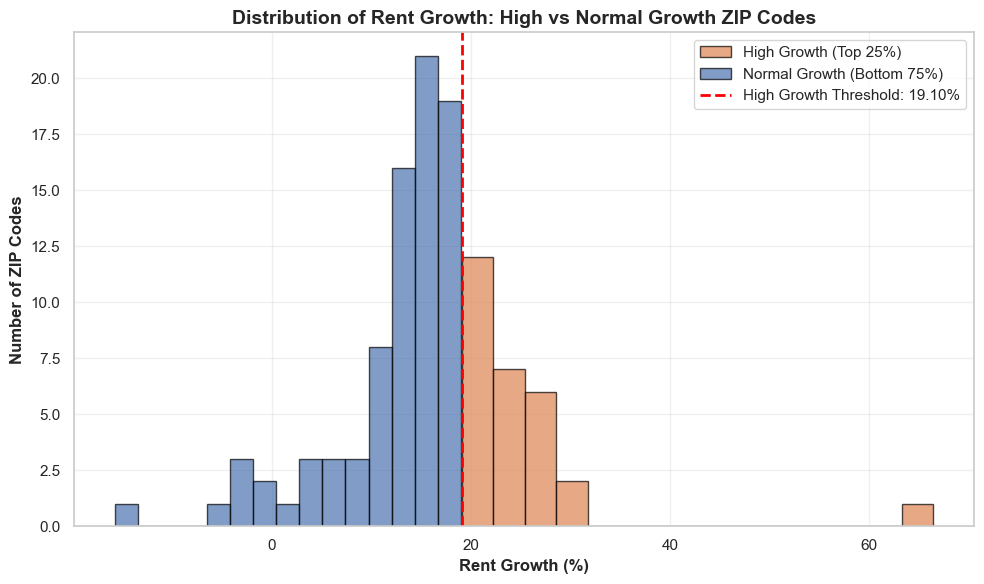

## 1. Rent Growth Labels

This section visualizes how we construct the **high growth** vs **normal growth** labels:

- Use ZORI rent data to compute `rent_growth` per ZIP over the chosen period
- Define **high growth** as the **top 25%** of ZIP codes by rent growth
- Remaining 75% are labeled **normal growth**

We first show the distribution of rent growth and the cutoff threshold.


In [60]:
# Intro stats about our data

# Number of ZIP codes in classification dataset
num_zip_class = class_df['zip'].nunique() if 'zip' in class_df.columns else class_df['RegionName'].nunique()
print(f"Number of unique ZIP codes in classification data: {num_zip_class}")

# Number of ZORI listings (i.e., ZIP codes with ZORI data)
raw_zori = pd.read_csv('./raw_data/Zip_zori_uc_sfrcondomfr_sm_month.csv')
num_zori_zips = raw_zori['RegionName'].nunique()
print(f"Number of unique ZIP codes in ZORI data: {num_zori_zips}")

# Number of Business listings, if available
try:
    bus_df = pd.read_csv("./data/cleaned_biz_summary.csv")
    num_biz = bus_df['zip'].nunique() if 'zip' in bus_df.columns else len(bus_df)
    print(f"Number of unique ZIP codes in business data: {num_biz}")
    print(f"Total number of businesses (if column count exists): {bus_df['business_count'].sum() if 'business_count' in bus_df.columns else 'N/A'}")
except Exception as e:
    print("Business data not found or error loading.")

# Convenience: print dataframe shapes
print(f"class_df shape: {class_df.shape}")
print(f"raw_zori shape: {raw_zori.shape}")



Number of unique ZIP codes in classification data: 109
Number of unique ZIP codes in ZORI data: 7822
Business data not found or error loading.
class_df shape: (109, 34)
raw_zori shape: (7822, 139)


In [54]:
raw_zori = pd.read_csv('./raw_data/Zip_zori_uc_sfrcondomfr_sm_month.csv')
raw_zori.columns

Index(['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName',
       'State', 'City', 'Metro', 'CountyName', '2015-01-31',
       ...
       '2025-01-31', '2025-02-28', '2025-03-31', '2025-04-30', '2025-05-31',
       '2025-06-30', '2025-07-31', '2025-08-31', '2025-09-30', '2025-10-31'],
      dtype='object', length=139)

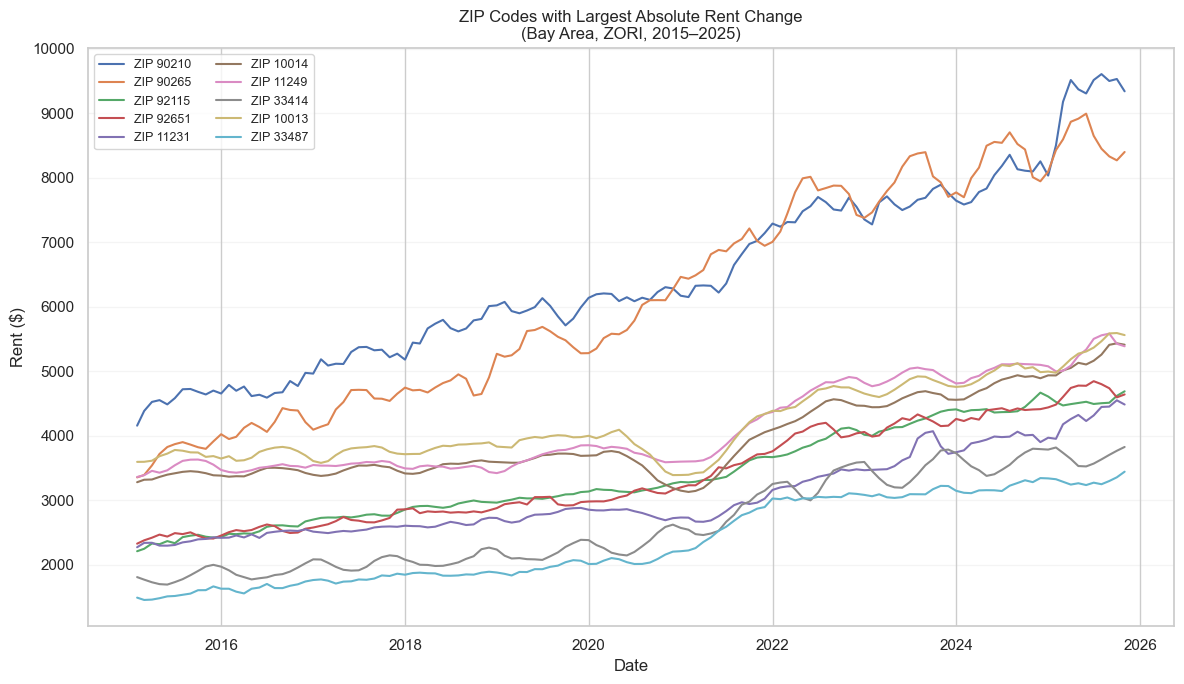

In [58]:
# Plot rent trends over time for 10 ZIP codes with largest absolute change (growth or decline)

# Identify columns that are dates (ZORI time series)
date_cols = [col for col in raw_zori.columns if col[:4].isdigit() and '-' in col and len(col) == 10]

# Compute rent change over the time period
zori_trends = raw_zori[["RegionName"] + date_cols].copy()
zori_trends["RegionName"] = zori_trends["RegionName"].astype(str)
zori_trends["rent_change"] = zori_trends[date_cols[-1]] - zori_trends[date_cols[0]]
zori_trends["abs_change"] = np.abs(zori_trends["rent_change"])

# Select top 10 ZIP codes by largest absolute change (positive or negative)
top10 = zori_trends.sort_values("abs_change", ascending=False).head(10)

# For these ZIPs, prepare data for plotting
plt.figure(figsize=(12, 7))
selected_zips = top10["RegionName"].astype(str).tolist()
for zip_code in selected_zips:
    # Fix: Check if the filtered DataFrame is not empty before accessing .iloc[0]
    row_match = zori_trends[zori_trends["RegionName"] == zip_code]
    if not row_match.empty:
        row = row_match.iloc[0]
        rents = row[date_cols].values.astype(float)
        plt.plot(pd.to_datetime(date_cols), rents, label=f"ZIP {zip_code}")
    else:
        print(f"Warning: ZIP code {zip_code} not found in zori_trends.")

plt.ylabel("Rent ($)")
plt.xlabel("Date")
plt.title("ZIP Codes with Largest Absolute Rent Change\n(Bay Area, ZORI, 2015–2025)")
plt.legend(loc='best', fontsize=9, ncol=2)
plt.grid(True, axis='y', alpha=0.2)
plt.tight_layout()
plt.show()


## 2. Model Performance Summary

This section summarizes how well different classifiers predict **high-growth ZIPs** using **only Yelp / business ecosystem features**.

We show:
- A table of metrics (Accuracy, Precision, Recall, F1, ROC-AUC)
- A bar chart of ROC-AUC by model

These visuals support the claim that Yelp signals carry real predictive power.


In [39]:
# Show metrics table
results_df


,model,train_accuracy,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,cv_roc_auc_mean,cv_roc_auc_std
0,Logistic Regression,0.666667,0.590909,0.461538,0.75,0.571429,0.750000,0.580632,0.041532
1,Random Forest,0.977011,0.500000,0.000000,0.00,0.000000,0.593750,0.642582,0.130314
2,Gradient Boosting,0.977011,0.590909,0.444444,0.50,0.470588,0.580357,0.597802,0.133434


/var/folders/qt/4phmshfn16z9fjyk1pjm4kpr0000gn/T/ipykernel_583/3339355428.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=order, x="model", y="test_roc_auc", palette="Blues_d")


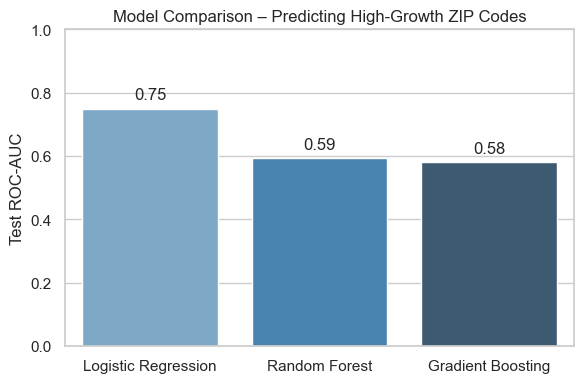

In [40]:
# ROC-AUC bar chart by model
plt.figure(figsize=(6, 4))
order = results_df.sort_values("test_roc_auc", ascending=False)
sns.barplot(data=order, x="model", y="test_roc_auc", palette="Blues_d")
plt.ylim(0.0, 1.0)
plt.ylabel("Test ROC-AUC")
plt.xlabel("")
plt.title("Model Comparison – Predicting High-Growth ZIP Codes")
for i, v in enumerate(order["test_roc_auc"]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


## 3. Yelp / Gentrification Feature Importance

This section visualizes which **Yelp-derived features** are most important for predicting high rent growth.

We use the pre-computed feature importance from the best model to:
- Show a bar chart of the top features
- Highlight signals like business quality, gentrification intensity, and high-price business density.


/var/folders/qt/4phmshfn16z9fjyk1pjm4kpr0000gn/T/ipykernel_583/2488698503.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, y="feature", x="importance", palette="viridis")


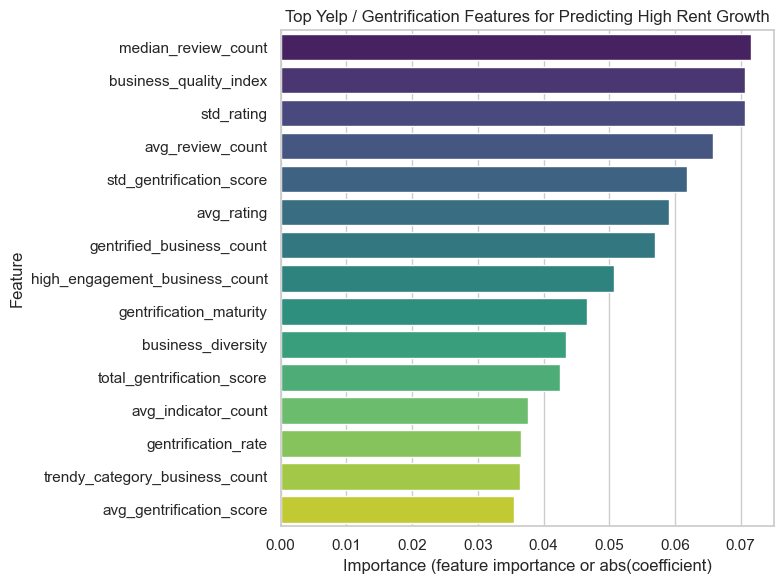

In [41]:
# Bar chart of top 15 most important features
plt.figure(figsize=(8, 6))

# Assume feat_imp_df has columns: feature, importance
top_k = 15
top_features = feat_imp_df.sort_values("importance", ascending=False).head(top_k)

sns.barplot(data=top_features, y="feature", x="importance", palette="viridis")
plt.xlabel("Importance (feature importance or abs(coefficient)")
plt.ylabel("Feature")
plt.title("Top Yelp / Gentrification Features for Predicting High Rent Growth")
plt.tight_layout()
plt.show()


## 4. Spatial Maps by ZIP Code

Finally, we create **maps** to show how:
- Rent growth is distributed geographically across Bay Area ZIP codes
- Yelp-based gentrification intensity lines up with those high-growth areas

We use `folium` for interactive maps and `pgeocode` to look up ZIP code centroids.

> Note: You may need to install dependencies first:
> `pip install folium pgeocode`



In [42]:
if folium is None or pgeocode is None:
    print("folium or pgeocode not installed. Run: pip install folium pgeocode")
else:
    # Follow the working pattern from first-draft/recommender.ipynb
    nomi = pgeocode.Nominatim("us")

    # Start from classification dataframe
    map_df = class_df.copy().reset_index(drop=True)

    # Query coordinates for each ZIP and attach as columns
    coord_df = nomi.query_postal_code(map_df["zip"].astype(str).tolist())
    map_df["latitude"] = coord_df["latitude"].values
    map_df["longitude"] = coord_df["longitude"].values

    # Drop any rows without valid coordinates
    map_df = map_df.dropna(subset=["latitude", "longitude"]).copy()

    print(f"ZIPs with coordinates: {len(map_df)} / {len(class_df)}")
    display(map_df[["zip", "latitude", "longitude"]].head())


ZIPs with coordinates: 109 / 109


,zip,latitude,longitude
0,94565,38.0031,-121.9172
1,94112,37.7195,-122.4411
2,95035,37.4352,-121.8950
3,94544,37.6374,-122.0670
4,94513,37.9324,-121.6894


In [43]:
if folium is not None and pgeocode is not None:
    if "map_df" not in globals() or map_df.empty:
        print("No valid coordinates found for any ZIPs; cannot draw map.")
    else:
        # Fixed Bay Area center (same as in first-draft recommender map)
        bay_center = [37.7749, -122.4194]

        # Map 1: Rent growth (continuous)
        rent_map = folium.Map(location=bay_center, zoom_start=10, tiles="cartodbpositron")

        # Normalize rent growth for coloring
        rg = map_df["rent_growth"]
        min_rg, max_rg = rg.min(), rg.max()

        def color_for_growth(g):
            # simple blue→red scale
            t = (g - min_rg) / (max_rg - min_rg + 1e-9)
            r = int(255 * t)
            b = int(255 * (1 - t))
            return f"#{r:02x}00{b:02x}"

        for _, row in map_df.iterrows():
            folium.CircleMarker(
                location=[row["latitude"], row["longitude"]],
                radius=5,
                color=color_for_growth(row["rent_growth"]),
                fill=True,
                fill_opacity=0.8,
                popup=f"ZIP {row['zip']}<br>Rent growth: {row['rent_growth']:.1%}",
            ).add_to(rent_map)

        display(rent_map)


In [44]:
if folium is not None and pgeocode is not None:
    if "map_df" not in globals() or map_df.empty:
        print("No valid coordinates found for any ZIPs; cannot draw map.")
    else:
        # Map 2: Yelp-based gentrification intensity
        if "gentrification_intensity" in map_df.columns:
            gent_col = "gentrification_intensity"
        else:
            gent_col = "total_gentrification_score" if "total_gentrification_score" in map_df.columns else None

        if gent_col is None:
            print("No gentrification intensity column found; cannot plot second map.")
        else:
            g = map_df[gent_col]
            min_g, max_g = g.min(), g.max()

            def color_for_gent(val):
                t = (val - min_g) / (max_g - min_g + 1e-9)
                r = int(128 * t)
                g_col = int(255 * (1 - t))
                b = int(128 + 127 * t)
                return f"#{r:02x}{g_col:02x}{b:02x}"

            bay_center = [37.7749, -122.4194]
            gent_map = folium.Map(location=bay_center, zoom_start=10, tiles="cartodbpositron")

            for _, row in map_df.iterrows():
                folium.CircleMarker(
                    location=[row["latitude"], row["longitude"]],
                    radius=5,
                    color=color_for_gent(row[gent_col]),
                    fill=True,
                    fill_opacity=0.8,
                    popup=f"ZIP {row['zip']}<br>{gent_col}: {row[gent_col]:.2f}",
                ).add_to(gent_map)

            display(gent_map)


In [74]:
# Map showing Actual vs Predicted class labels
# Simple approach: use class_df directly and show actual labels
# For predictions, we'll use a simple heuristic or load from saved results

if folium is not None and pgeocode is not None:
    # Use the same coordinate lookup as the other maps
    if "map_df" not in globals() or map_df.empty:
        nomi = pgeocode.Nominatim("us")
        pred_df = class_df.copy().reset_index(drop=True)
        coord_df = nomi.query_postal_code(pred_df["zip"].astype(str).tolist())
        pred_df["latitude"] = coord_df["latitude"].values
        pred_df["longitude"] = coord_df["longitude"].values
        pred_df = pred_df.dropna(subset=["latitude", "longitude"]).copy()
    else:
        pred_df = class_df.merge(map_df[['zip', 'latitude', 'longitude']], on='zip', how='left')
        pred_df = pred_df.dropna(subset=["latitude", "longitude"]).copy()
    
    print(f"✓ ZIP codes with coordinates: {len(pred_df)} / {len(class_df)}")
    
    # For now, show actual labels - you can add predictions later if needed
    # Actual label is in 'high_growth' column
    pred_df['actual'] = pred_df['high_growth']
    
    # Do not save pred_df or map to disk, just visualize interactively
    
    # Create map
    bay_center = [37.7749, -122.4194]
    pred_map = folium.Map(location=bay_center, zoom_start=10, tiles="cartodbpositron")
    
    # Color scheme: Red/Blue for actual class, marker size for gentrification intensity
    # Get gentrification intensity/rate for visualization
    gent_col = 'gentrification_intensity' if 'gentrification_intensity' in pred_df.columns else 'gentrification_rate'
    if gent_col not in pred_df.columns:
        gent_col = 'total_gentrification_score' if 'total_gentrification_score' in pred_df.columns else None
    
    if gent_col:
        gent_values = pred_df[gent_col].fillna(0)
        min_gent = gent_values.min()
        max_gent = gent_values.max()
        # Normalize for marker size (5 to 15 radius)
        def get_marker_size(gent_val):
            if max_gent == min_gent:
                return 8
            t = (gent_val - min_gent) / (max_gent - min_gent + 1e-9)
            return 5 + t * 10  # Range: 5 to 15
    else:
        get_marker_size = lambda x: 8
    
    for _, row in pred_df.iterrows():
        actual = int(row['actual']) if pd.notna(row['actual']) else 0
        rent_growth = row['rent_growth'] if pd.notna(row['rent_growth']) else 0
        
        # Color by actual class
        color = 'red' if actual == 1 else 'blue'
        
        # Marker size based on gentrification intensity/rate
        if gent_col:
            gent_val = row[gent_col] if pd.notna(row[gent_col]) else 0
            marker_size = get_marker_size(gent_val)
            gent_rate = row.get('gentrification_rate', 0) if pd.notna(row.get('gentrification_rate', 0)) else 0
        else:
            marker_size = 8
            gent_val = 0
            gent_rate = 0
        
        # Create popup with actual label and gentrification info
        popup_html = (
            f"<strong>ZIP {row['zip']}</strong><br>"
            f"<b>Actual Class:</b> {'High Growth (Gentrification)' if actual == 1 else 'Normal Growth'}<br>"
            f"<b>Rent Growth:</b> {rent_growth:.1%}<br>"
        )
        if gent_col:
            popup_html += f"<b>{gent_col.replace('_', ' ').title()}:</b> {gent_val:.3f}<br>"
        if 'gentrification_rate' in pred_df.columns:
            popup_html += f"<b>Gentrification Rate:</b> {gent_rate:.1%}<br>"
        
        folium.CircleMarker(
            location=[row["latitude"], row["longitude"]],
            radius=marker_size,
            color='black',
            weight=2,
            fill=True,
            fillColor=color,
            fillOpacity=0.7,
            popup=folium.Popup(popup_html, max_width=300)
        ).add_to(pred_map)
    
    # Add legend
    legend_html = f'''
    <div style="position: fixed; 
                bottom: 50px; left: 50px; width: 220px; height: 120px; 
                background-color: white; border:2px solid grey; z-index:9999; 
                font-size:14px; padding: 10px">
    <h4>Map Legend</h4>
    <p><span style="color:red;">●</span> High Growth (Top 25%)</p>
    <p><span style="color:blue;">●</span> Normal Growth (Bottom 75%)</p>
    <p><b>Marker Size:</b> Gentrification Intensity</p>
    <p style="font-size:11px;">(Larger = Higher Intensity)</p>
    </div>
    '''
    pred_map.get_root().html.add_child(folium.Element(legend_html))
    
    # Save map to HTML file
    map_output_path = Path("outputs") / "actual_class_gentrification_map.html"
    map_output_path.parent.mkdir(parents=True, exist_ok=True)
    pred_map.save(str(map_output_path))
    print(f"✓ Map saved to: {map_output_path}")
    
    display(pred_map)
    
    # Print summary
    print("\n" + "="*70)
    print("ACTUAL CLASS DISTRIBUTION")
    print("="*70)
    print(f"Total ZIP codes: {len(pred_df)}")
    print(f"High Growth (Red): {pred_df['actual'].sum()} ({pred_df['actual'].mean():.1%})")
    print(f"Normal Growth (Blue): {(pred_df['actual'] == 0).sum()} ({(pred_df['actual'] == 0).mean():.1%})")
else:
    print("folium or pgeocode not installed. Run: pip install folium pgeocode")


✓ ZIP codes with coordinates: 109 / 109
✓ Map saved to: outputs/actual_class_gentrification_map.html



ACTUAL CLASS DISTRIBUTION
Total ZIP codes: 109
High Growth (Red): 28 (25.7%)
Normal Growth (Blue): 81 (74.3%)


## 5. Talking Points for the Presentation

You can structure your 4‑minute talk while scrolling through this notebook:

1. **Research Question (Slide 1)**  
   - “Can Yelp business data help us identify gentrifying neighborhoods (high rent growth ZIPs)?”

2. **Data & Labels (Slides 2–3)**  
   - Use the rent growth histogram and class balance plot to explain how labels are constructed.

3. **Model Performance (Slide 4)**  
   - Use the metrics table and ROC-AUC bar chart to show that Yelp features have predictive power.

4. **Which Yelp Signals Matter? (Slide 5)**  
   - Use the feature importance bar chart to point to business quality, gentrification intensity, premium business density, etc.

5. **Spatial Story (Slides 6–7)**  
   - Use the two folium maps to show how high-growth areas line up with high gentrification intensity scores.

6. **Conclusion (Slide 8)**  
   - Summarize: “Yes – Yelp’s business ecosystem signals (trendy, high‑end, highly rated places) help predict where rent will rise fastest.”

